# Grading System Simulation

Simulates 10 users scoring 1000 items (true values in **[-2, +2]**).
Each item is an entry in a dict: `scores[item_id][user_id] = score`. Each user scores
an item at most once.

Users always pick the **least-voted item** they haven't scored yet (ties broken randomly).
With probability *p* a user scores the nearest integer above or below the true value;
otherwise they score a random integer in [-3, +3].

We track how well the **mean** and **median** of collected scores recover the true values over M weeks (5 working days per week).

In [224]:
import math

import matplotlib.pyplot as plt
import numpy as np

# ── Simulation parameters (edit these) ──────────────────────────────
N_ITEMS = 1000  # number of items to score
N_USERS = 15  # number of users
N_PER_DAY = 20  # scores each user submits per day
DAYS_PER_WEEK = 5  # working days in a week
M_WEEKS = 36  # number of weeks the simulation runs
ACCURACY = 0.5  # probability a user scores "close" (floor/ceil of true value)
PRECISION = 1.5  # half-width of random perturbation applied to true value when scoring close
REMOVAL_INTERVAL = 4  # remove votes every I weeks (0 to disable)
REMOVAL_COUNT = 100  # number of individual votes removed each time
SEED = 42  # RNG seed for reproducibility

# Per-user accuracy overrides (length must equal N_USERS).
# Set to None to give every user the same ACCURACY.
USER_ACCURACIES: list[float] | None = None

## Generate true data

1000 items with true scores uniformly spaced from -3 to +3.

In [225]:
def linear_target(i: int, n_items: int) -> float:
    """Linearly spaced from -2 to +2."""
    return -2 + 4 * i / (n_items - 1)


def sinusoidal_target(i: int, n_items: int) -> float:
    """One full sine wave mapped to [-2, +2]."""
    return 2 * math.sin(2 * math.pi * i / (n_items - 1))


def quadratic_target(i: int, n_items: int) -> float:
    """Parabola: -2 at edges, +2 at center."""
    t = 2 * i / (n_items - 1) - 1  # normalized to [-1, +1]
    return -2 + 4 * (1 - t * t)


def step_target(i: int, n_items: int) -> float:
    """Three discrete plateaus: -2, 0, +2."""
    third = n_items // 3
    if i < third:
        return -2.0
    if i < 2 * third:
        return 0.0
    return 2.0


def exponential_target(i: int, n_items: int) -> float:
    """Exponential curve from -2 to +2."""
    t = i / (n_items - 1)  # [0, 1]
    return -2 + 4 * (math.exp(t) - 1) / (math.e - 1)


def logistic_target(i: int, n_items: int, k: float = 10.0) -> float:
    """Logistic (S-curve) from -2 to +2. k controls steepness."""
    t = i / (n_items - 1)  # [0, 1]
    s = 1 / (1 + math.exp(-k * (t - 0.5)))
    return -2 + 4 * s


# ── Swap target_function to any of the above ────────────────────────
target_function = linear_target

true_values: dict[int, float] = {i: target_function(i, N_ITEMS) for i in range(N_ITEMS)}

# Also keep an array form for vectorised plotting later
true_scores_arr = np.array([true_values[i] for i in range(N_ITEMS)])

rng = np.random.default_rng(SEED)

user_ids = [f"u{i}" for i in range(N_USERS)]
accuracies = (
    {uid: p for uid, p in zip(user_ids, USER_ACCURACIES)}
    if USER_ACCURACIES is not None
    else dict.fromkeys(user_ids, ACCURACY)
)
assert len(accuracies) == N_USERS

print(f"Items:  {N_ITEMS}")
print(f"Users:  {user_ids}")
print(f"Accuracies: {accuracies}")
M_DAYS = DAYS_PER_WEEK * M_WEEKS
print(f"Weeks: {M_WEEKS} ({DAYS_PER_WEEK} days/week = {M_DAYS} days)")
print(f"Scores: {N_PER_DAY}/user/day × {M_DAYS} days = {N_PER_DAY * M_DAYS} max per user")
print(f"Total possible scores: {N_USERS * N_PER_DAY * M_DAYS}")

Items:  1000
Users:  ['u0', 'u1', 'u2', 'u3', 'u4', 'u5', 'u6', 'u7', 'u8', 'u9', 'u10', 'u11', 'u12', 'u13', 'u14']
Accuracies: {'u0': 0.5, 'u1': 0.5, 'u2': 0.5, 'u3': 0.5, 'u4': 0.5, 'u5': 0.5, 'u6': 0.5, 'u7': 0.5, 'u8': 0.5, 'u9': 0.5, 'u10': 0.5, 'u11': 0.5, 'u12': 0.5, 'u13': 0.5, 'u14': 0.5}
Weeks: 36 (5 days/week = 180 days)
Scores: 20/user/day × 180 days = 3600 max per user
Total possible scores: 54000


## Simulate scoring

For each day, each user picks N items using the **least-voted-first** strategy
(among items the user hasn't scored yet) and assigns a score according to the accuracy model.

Every **I** weeks, **X** random individual votes are removed from the dataset
(a single entry like `scores[item][user]`, not all votes from a user).

In [226]:
def p_minus_absolute_difference(candidate: int, true_val: float) -> float:
    """Closeness weight: 1 - |candidate - true_val|."""
    return 1.0 - abs(candidate - true_val)


def score_item(true_val: float, accuracy: float, precision: float, rng: np.random.Generator) -> int:
    """Return an integer score in [-3, +3] for an item with the given true value."""
    if rng.random() < accuracy:
        perturbed = true_val + rng.uniform(-precision, precision)
        perturbed = max(-3.0, min(3.0, perturbed))
        lo, hi = math.floor(perturbed), math.ceil(perturbed)
        if lo == hi:
            return lo
        w_lo = p_minus_absolute_difference(lo, perturbed)
        w_hi = p_minus_absolute_difference(hi, perturbed)
        total = w_lo + w_hi
        return hi if rng.random() < (w_hi / total) else lo
    return int(rng.integers(-3, 4))


def snapshot(scores: dict[int, dict[str, int]], n_items: int) -> tuple[np.ndarray, np.ndarray]:
    """Compute per-item mean and median arrays from the current scores dict."""
    means = np.full(n_items, np.nan)
    medians = np.full(n_items, np.nan)
    for i in range(n_items):
        vals = list(scores[i].values())
        if vals:
            means[i] = np.mean(vals)
            medians[i] = np.median(vals)
    return means, medians


# scores[item_id][user_id] = integer score
scores: dict[int, dict[str, int]] = {i: {} for i in range(N_ITEMS)}

day_snapshots: list[tuple[np.ndarray, np.ndarray]] = []

for day in range(M_DAYS):
    for uid in user_ids:
        p = accuracies[uid]
        for _ in range(N_PER_DAY):
            unscored = [i for i in range(N_ITEMS) if uid not in scores[i]]
            if not unscored:
                break
            min_votes = min(len(scores[i]) for i in unscored)
            candidates = [i for i in unscored if len(scores[i]) == min_votes]
            pick = int(rng.choice(candidates))
            scores[pick][uid] = score_item(true_values[pick], p, PRECISION, rng)

    week_num = (day + 1) // DAYS_PER_WEEK
    is_end_of_week = (day + 1) % DAYS_PER_WEEK == 0
    if REMOVAL_INTERVAL and is_end_of_week and week_num % REMOVAL_INTERVAL == 0:
        all_votes = [(i, uid) for i in range(N_ITEMS) for uid in scores[i]]
        n_to_remove = min(REMOVAL_COUNT, len(all_votes))
        if n_to_remove:
            indices = rng.choice(len(all_votes), size=n_to_remove, replace=False)
            for idx in indices:
                item_id, user_id = all_votes[idx]
                del scores[item_id][user_id]

    day_snapshots.append(snapshot(scores, N_ITEMS))

total_scores = sum(len(v) for v in scores.values())
print(f"Simulation complete: {M_DAYS} days, {total_scores} total scores recorded.")
print(f"Example: scores[37] = {scores[37]}")

Simulation complete: 180 days, 14900 total scores recorded.
Example: scores[37] = {'u3': -3, 'u1': 1, 'u0': -3, 'u2': -1, 'u10': 1, 'u5': 0, 'u4': -3, 'u12': 0, 'u11': -1, 'u7': -3, 'u14': -1, 'u13': 0, 'u6': 0, 'u8': -2, 'u9': -1}


## Compute final aggregates

In [227]:
final_means, final_medians = day_snapshots[-1]

scored_mask = ~np.isnan(final_means)
n_scored = scored_mask.sum()

mean_errors = final_means[scored_mask] - true_scores_arr[scored_mask]
median_errors = final_medians[scored_mask] - true_scores_arr[scored_mask]

print(f"Items with ≥1 score: {n_scored} / {N_ITEMS}")
print(
    f"Mean estimator  — MAE: {np.mean(np.abs(mean_errors)):.3f},  bias: {np.mean(mean_errors):+.3f}"
)
print(
    f"Median estimator — MAE: {np.mean(np.abs(median_errors)):.3f},  bias: {np.mean(median_errors):+.3f}"
)

Items with ≥1 score: 1000 / 1000
Mean estimator  — MAE: 0.612,  bias: +0.001
Median estimator — MAE: 0.565,  bias: +0.002


## Histograms — Error distributions for mean vs median estimators

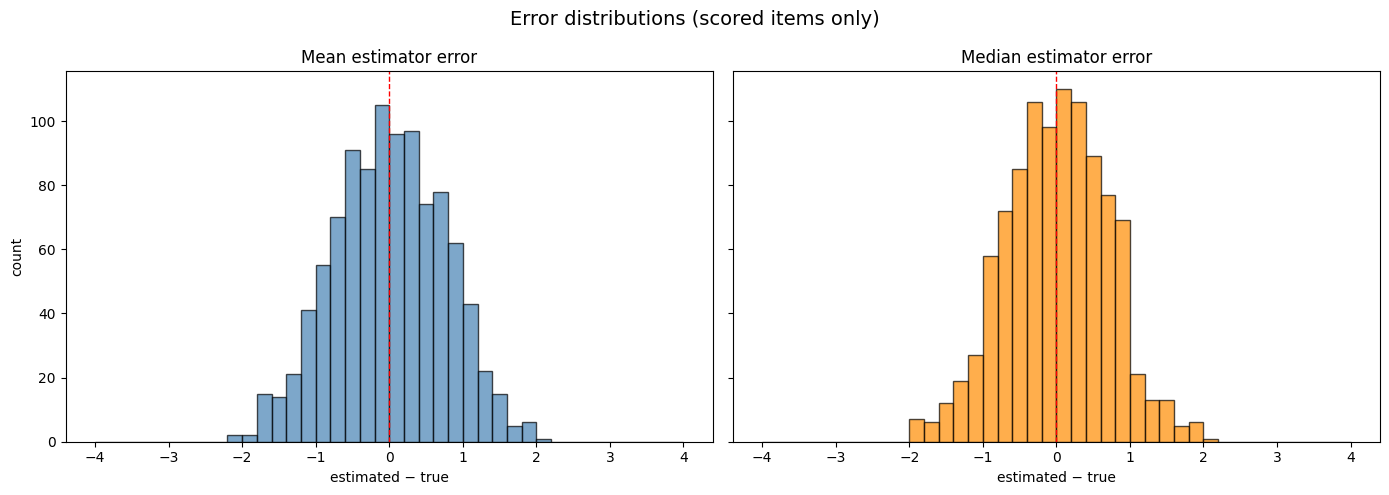

In [228]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bins = np.linspace(-4, 4, 41)

axes[0].hist(mean_errors, bins=bins, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Mean estimator error")
axes[0].set_xlabel("estimated − true")
axes[0].set_ylabel("count")

axes[1].hist(median_errors, bins=bins, edgecolor="black", alpha=0.7, color="darkorange")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Median estimator error")
axes[1].set_xlabel("estimated − true")

fig.suptitle("Error distributions (scored items only)", fontsize=14)
fig.tight_layout()
plt.show()

## Recovery plot — Target function vs mean and median estimates

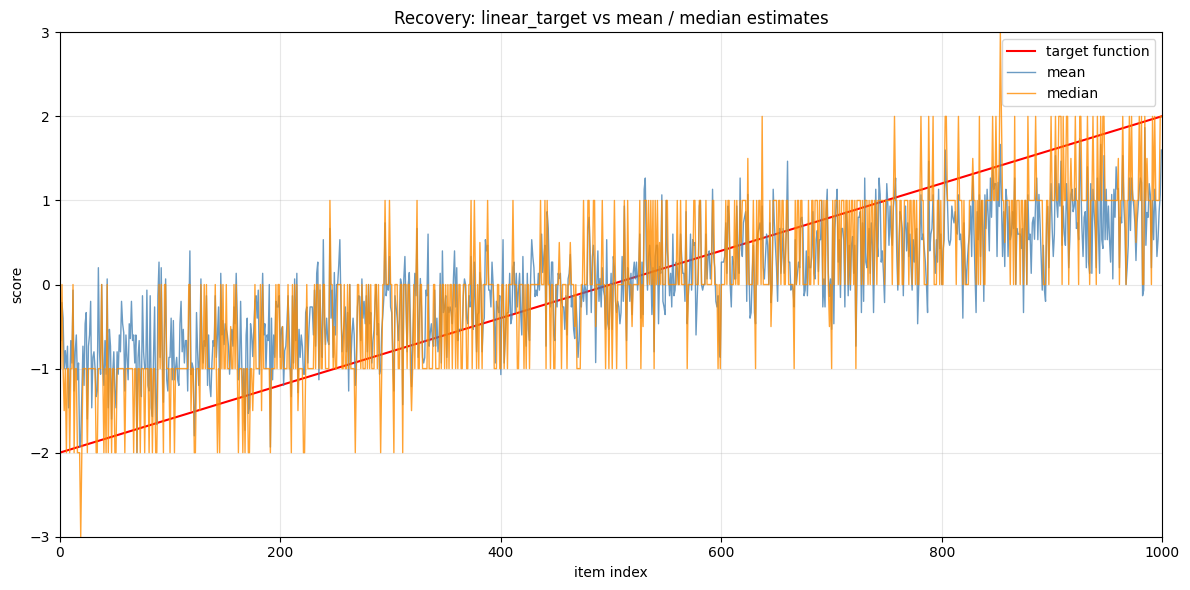

In [229]:
items = np.arange(N_ITEMS)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(items, true_scores_arr, "r-", linewidth=1.5, label="target function")
ax.plot(
    items[scored_mask],
    final_means[scored_mask],
    linewidth=1,
    alpha=0.8,
    color="steelblue",
    label="mean",
)
ax.plot(
    items[scored_mask],
    final_medians[scored_mask],
    linewidth=1,
    alpha=0.8,
    color="darkorange",
    label="median",
)
ax.set_xlim(0, N_ITEMS)
ax.set_ylim(-3, 3)
ax.set_xlabel("item index")
ax.set_ylabel("score")
ax.set_title(f"Recovery: {target_function.__name__} vs mean / median estimates")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Convergence — MAE over weeks

How quickly do the mean and median estimators improve as more scores come in?

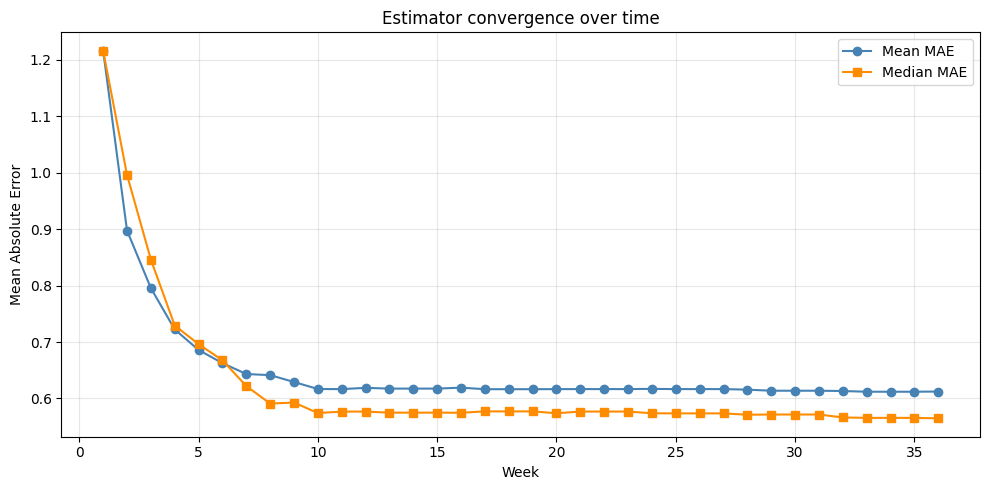

In [230]:
week_mean_maes = []
week_median_maes = []

for week in range(M_WEEKS):
    end_of_week_idx = (week + 1) * DAYS_PER_WEEK - 1
    day_means, day_medians = day_snapshots[end_of_week_idx]
    mask = ~np.isnan(day_means)
    if mask.any():
        week_mean_maes.append(np.mean(np.abs(day_means[mask] - true_scores_arr[mask])))
        week_median_maes.append(np.mean(np.abs(day_medians[mask] - true_scores_arr[mask])))
    else:
        week_mean_maes.append(np.nan)
        week_median_maes.append(np.nan)

weeks = np.arange(1, M_WEEKS + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weeks, week_mean_maes, "o-", color="steelblue", label="Mean MAE")
ax.plot(weeks, week_median_maes, "s-", color="darkorange", label="Median MAE")
ax.set_xlabel("Week")
ax.set_ylabel("Mean Absolute Error")
ax.set_title("Estimator convergence over time")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Coverage statistics

How many items were actually scored, and how are scores distributed across items?

Items with ≥1 score: 1000 / 1000
Items with 0 scores: 0
Scores per item — min: 13, max: 15, mean: 14.9, median: 15


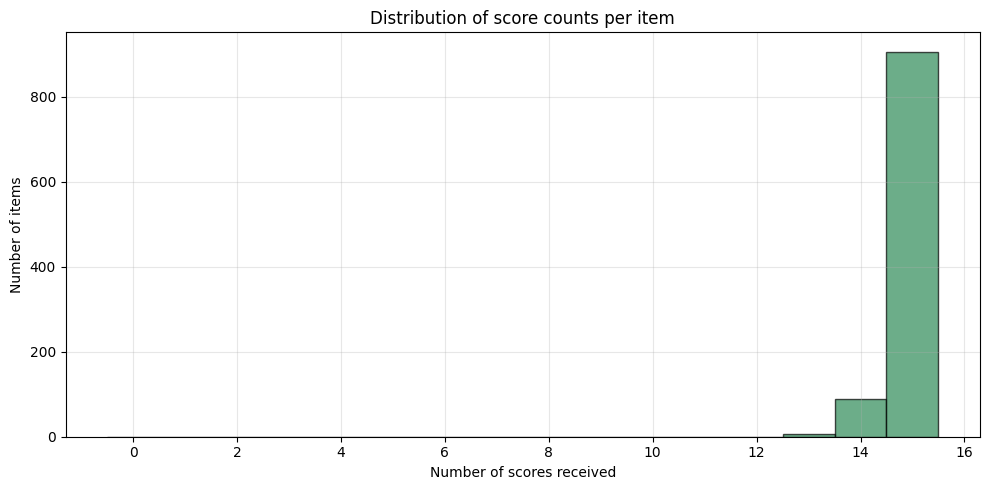

In [231]:
counts = np.array([len(scores[i]) for i in range(N_ITEMS)])

print(f"Items with ≥1 score: {(counts > 0).sum()} / {N_ITEMS}")
print(f"Items with 0 scores: {(counts == 0).sum()}")
print(
    f"Scores per item — min: {counts.min()}, max: {counts.max()}, "
    f"mean: {counts.mean():.1f}, median: {np.median(counts):.0f}"
)

fig, ax = plt.subplots(figsize=(10, 5))
max_count = counts.max()
ax.hist(
    counts, bins=np.arange(-0.5, max_count + 1.5, 1), edgecolor="black", alpha=0.7, color="seagreen"
)
ax.set_xlabel("Number of scores received")
ax.set_ylabel("Number of items")
ax.set_title("Distribution of score counts per item")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()